# Interactive Teaching Enhancements
## Learning Objectives
- Live Coding
- Pair Programming
- Mini Challenge
- Debugging Exercise
- AI Prompt Box
- Reflection

### 👥 Pair Programming
Student A writes code, Student B reviews, then switch.

### 🚧 Live Coding
Start from an empty cell and build the solution together.

### 🐞 Debugging Challenge
Purposely break one line of code and ask students to fix it.

### 🤖 AI Prompt
Ask ChatGPT to improve the solution, then verify it.

### 📝 Reflection
What did you learn? What would you improve?


# Charting in Colaboratory

A common use for notebooks is data visualization using charts. Colaboratory makes this easy with several charting tools available as Python imports.

In [ ]:
import altair as alt

source = {
    "values": [
        {"a": "A", "b": 28},
        {"a": "B", "b": 55},
        {"a": "C", "b": 43},
        {"a": "D", "b": 91},
        {"a": "E", "b": 81},
        {"a": "F", "b": 53},
        {"a": "G", "b": 19},
        {"a": "H", "b": 87},
        {"a": "I", "b": 52},
    ]
}

select = alt.selection_point(name="select", on="click")
highlight = alt.selection_point(name="highlight", on="pointerover", empty=False)

stroke_width = (
    alt.when(select).then(alt.value(2, empty=False))
    .when(highlight).then(alt.value(1))
    .otherwise(alt.value(0))
)


alt.Chart(source, height=200).mark_bar(
    fill="#4C78A8", stroke="black", cursor="pointer"
).encode(
    x="a:O",
    y="b:Q",
    fillOpacity=alt.when(select).then(alt.value(1)).otherwise(alt.value(0.3)),
    strokeWidth=stroke_width,
).configure_scale(bandPaddingInner=0.2).add_params(select, highlight)

alt.Chart(...)

In [ ]:
import altair as alt
import numpy as np
import pandas as pd

# Compute x^2 + y^2 across a 2D grid
x, y = np.meshgrid(range(-5, 5), range(-5, 5))
z = x ** 2 + y ** 2

# Convert this grid to columnar data expected by Altair
source = pd.DataFrame({'x': x.ravel(),
                     'y': y.ravel(),
                     'z': z.ravel()})

alt.Chart(source).mark_rect().encode(
    x='x:O',
    y='y:O',
    color='z:Q'
)
# No channel encoding options are specified in this chart
# so the code is the same as for the method-based syntax.

alt.Chart(...)

In [ ]:
import altair as alt
from vega_datasets import data

# Data source
source = data.gapminder.url

# X-value slider
x_slider = alt.binding_range(min=1955, max=2005, step=5, name='Year ')
x_select = alt.selection_point(name="x_select", fields=['year'], bind=x_slider, value=1980)

# Hover selection
hover = alt.selection_point(on='mouseover', fields=['country'], empty=False)
# A separate hover for the points since these need empty=True
hover_point_opacity = alt.selection_point(on='mouseover', fields=['country'])

# Search box for country name
search_box = alt.param(
    value='',
    bind=alt.binding(input='search', placeholder="Country", name='Search ')
)

# Base chart
base = alt.Chart(source).encode(
    alt.X('fertility:Q').scale(zero=False).title('Babies per woman (total fertility rate)'),
    alt.Y('life_expect:Q').scale(zero=False).title('Life expectancy'),
    alt.Color('region:N').scale(scheme='dark2').legend(orient='bottom-left', titleFontSize=14, labelFontSize=12).title('Region'),
    alt.Detail('country:N')
).transform_calculate(
    region="""{0}: 'South Asia',
        '1': 'Europe & Central Asia',
        '2': 'Sub-Saharan Africa',
        '3': 'The Americas',
        '4': 'East Asia & Pacific',
        '5': 'Middle East & North Africa'
    }[datum.cluster]"""
).transform_filter(
    # Exclude North Korea and South Korea due to source data error
    "datum.country !== 'North Korea' && datum.country !== 'South Korea'"
)

search_matches = alt.expr.test(alt.expr.regexp(search_box, "i"), alt.datum.country)
opacity = (
    alt.when(hover_point_opacity, search_matches)
    .then(alt.value(0.8))
    .otherwise(alt.value(0.1))
)
# Points that are always visible (filtered by slider and search)
visible_points = base.mark_circle(size=100).encode(
    opacity=opacity
    ).transform_filter(
        x_select
    ).add_params(
        hover,
        hover_point_opacity,
        x_select
)

when_hover = alt.when(hover)
hover_line = alt.layer(
    # Line layer
    base.mark_trail().encode(
        alt.Order('year:Q').sort('ascending'),
        alt.Size('year:Q').scale(domain=[1955, 2005], range=[1, 12]).legend(None),
        opacity=when_hover.then(alt.value(0.3)).otherwise(alt.value(0)),
        color=alt.value('#222222')
    ),
    # Point layer
    base.mark_point(size=50).encode(
        opacity=when_hover.then(alt.value(0.8)).otherwise(alt.value(0)),
    )
)

# Year labels
year_labels = base.mark_text(align='left', dx=5, dy=-5, fontSize=14).encode(
    text='year:O',
    color=alt.value('#222222')
).transform_filter(hover)

# Country labels
country_labels = alt.Chart(source).mark_text(
    align='left',
    dx=-15,
    dy=-25,
    fontSize=18,
    fontWeight='bold'
).encode(
    x='fertility:Q',
    y='life_expect:Q',
    text='country:N',
    color=alt.value('black'),
    opacity=when_hover.then(alt.value(1)).otherwise(alt.value(0))
).transform_window(
    rank='rank(life_expect)',
    sort=[alt.SortField('life_expect', order='descending')],
    groupby=['country'] # places label atop highest point on y-axis on hover
).transform_filter(
    alt.datum.rank == 1
).transform_aggregate(
    life_expect='max(life_expect)',
    fertility='max(fertility)',
    groupby=['country']
)

background_year = alt.Chart(source).mark_text(
    baseline='middle',
    fontSize=96,
    opacity=0.2
).encode(
    text='year:O'
).transform_filter(
    x_select
).transform_aggregate(
    year='max(year)'
)

# Combine all layers
chart = alt.layer(
    visible_points, year_labels, country_labels, hover_line, background_year
).properties(
    width=500,
    height=500,
    padding=10  # Padding ensures labels fit
).configure_axis(
    labelFontSize=12,
    titleFontSize=12
).add_params(search_box)

chart

alt.LayerChart(...)

## Matplotlib

[Matplotlib](http://matplotlib.org/) is the most common charting package, see its [documentation](http://matplotlib.org/api/pyplot_api.html) for details, and its [examples](http://matplotlib.org/gallery.html#statistics) for inspiration.

### Line Plots

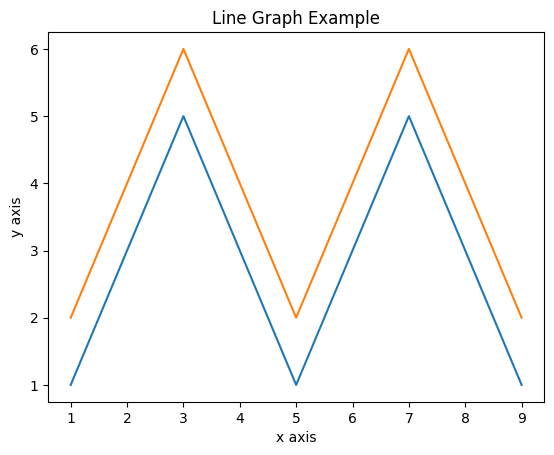

In [ ]:
import matplotlib.pyplot as plt

x  = [1, 2, 3, 4, 5, 6, 7, 8, 9]
y1 = [1, 3, 5, 3, 1, 3, 5, 3, 1]
y2 = [2, 4, 6, 4, 2, 4, 6, 4, 2]
plt.plot(x, y1, label="line L")
plt.plot(x, y2, label="line H")
plt.plot()

plt.xlabel("x axis")
plt.ylabel("y axis")
plt.title("Line Graph Example")
plt.show()

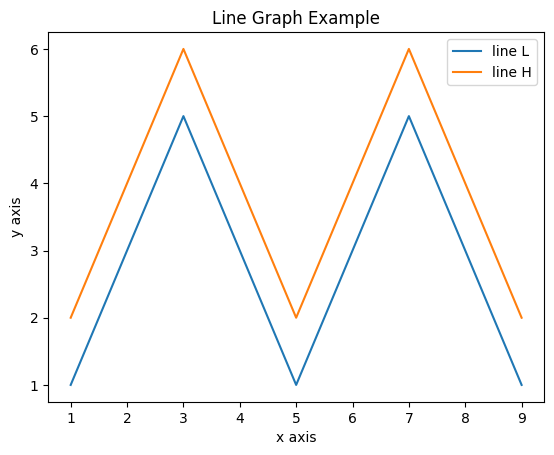

In [ ]:
import matplotlib.pyplot as plt

x  = [1, 2, 3, 4, 5, 6, 7, 8, 9]
y1 = [1, 3, 5, 3, 1, 3, 5, 3, 1]
y2 = [2, 4, 6, 4, 2, 4, 6, 4, 2]
plt.plot(x, y1, label="line L")
plt.plot(x, y2, label="line H")
plt.plot()

plt.xlabel("x axis")
plt.ylabel("y axis")
plt.title("Line Graph Example")
plt.legend()
plt.show()

### Bar Plots

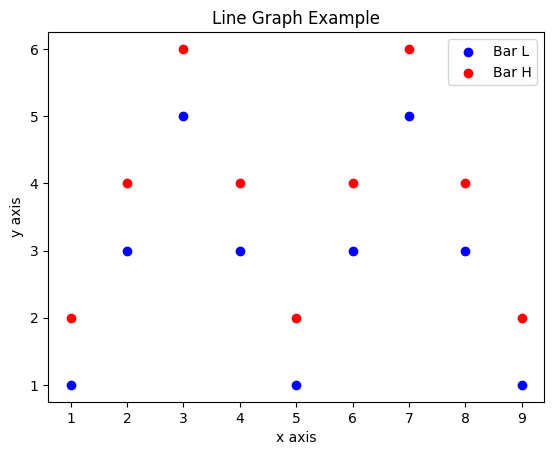

In [ ]:
import matplotlib.pyplot as plt

x1  = [1, 2, 3, 4, 5, 6, 7, 8, 9]
y1 = [1, 3, 5, 3, 1, 3, 5, 3, 1]
x2  = [1, 3, 3, 4, 6, 6, 7, 10, 9]
y2 = [2, 4, 6, 4, 2, 4, 6, 4, 2]

plt.scatter(x, y1, label="Bar L", color = 'b')
plt.scatter(x, y2, label="Bar H", color = 'r')
plt.plot()

plt.xlabel("x axis")
plt.ylabel("y axis")
plt.title("Line Graph Example")
plt.legend()
plt.show()

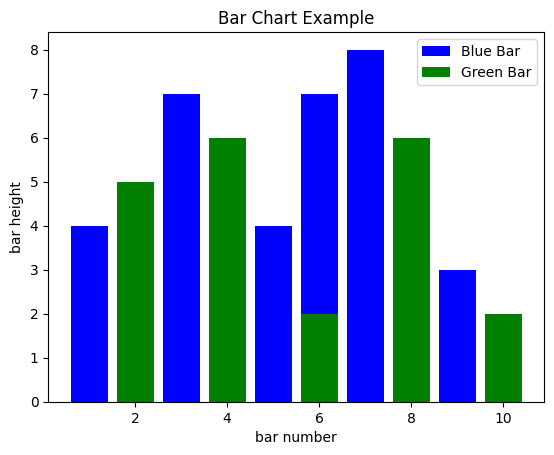

In [ ]:
import matplotlib.pyplot as plt

# Look at index 4 and 6, which demonstrate overlapping cases.
x1 = [1, 3, 4, 5, 6, 7, 9]
y1 = [4, 7, 2, 4, 7, 8, 3]

x2 = [2, 4, 6, 8, 10]
y2 = [5, 6, 2, 6, 2]

# Colors: https://matplotlib.org/api/colors_api.html

plt.bar(x1, y1, label="Blue Bar", color='b')
plt.bar(x2, y2, label="Green Bar", color='g')
plt.plot()

plt.xlabel("bar number")
plt.ylabel("bar height")
plt.title("Bar Chart Example")
plt.legend()
plt.show()

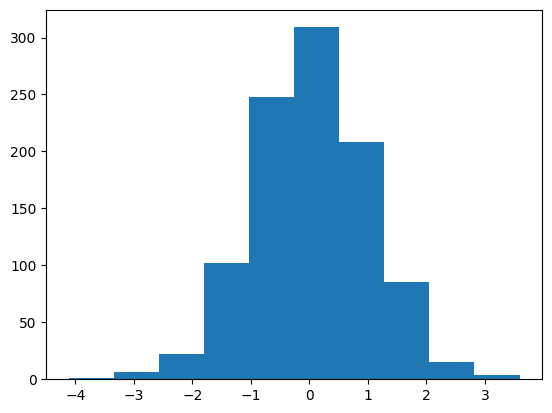

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
n = np.random.randn(1000)
plt.hist(n, bins=10)
plt.show()

### Histograms

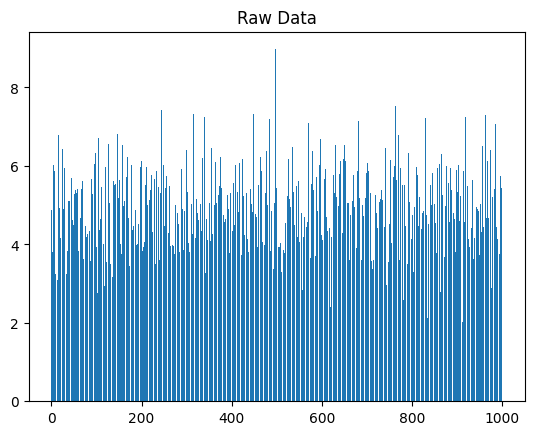

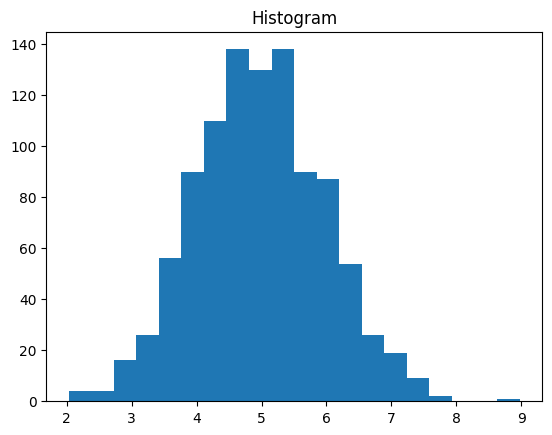

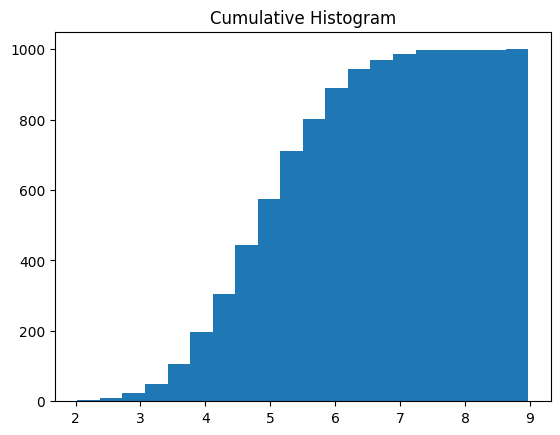

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Use numpy to generate a bunch of random data in a bell curve around 5.
n = 5 + np.random.randn(1000)

m = [m for m in range(len(n))]
plt.bar(m, n)
plt.title("Raw Data")
plt.show()

plt.hist(n, bins=20)
plt.title("Histogram")
plt.show()

plt.hist(n, cumulative=True, bins=20)
plt.title("Cumulative Histogram")
plt.show()

### Scatter Plots

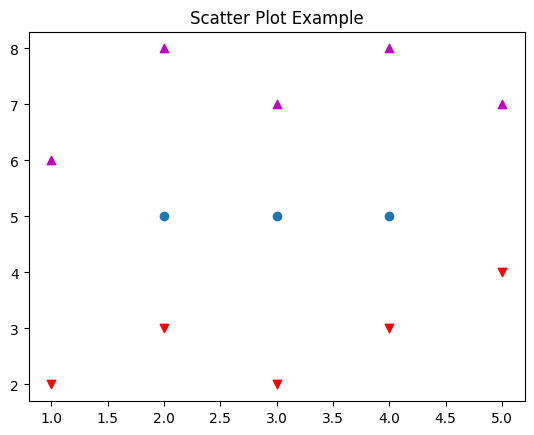

In [ ]:
import matplotlib.pyplot as plt

x1 = [2, 3, 4]
y1 = [5, 5, 5]

x2 = [1, 2, 3, 4, 5]
y2 = [2, 3, 2, 3, 4]
y3 = [6, 8, 7, 8, 7]

# Markers: https://matplotlib.org/api/markers_api.html

plt.scatter(x1, y1)
plt.scatter(x2, y2, marker='v', color='r')
plt.scatter(x2, y3, marker='^', color='m')
plt.title('Scatter Plot Example')
plt.show()

### Stack Plots

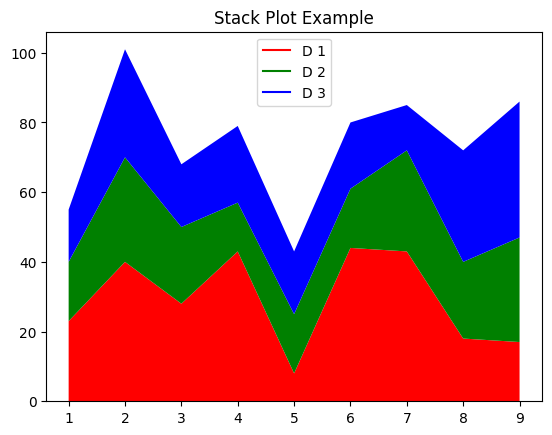

In [ ]:
import matplotlib.pyplot as plt

idxes = [ 1,  2,  3,  4,  5,  6,  7,  8,  9]
arr1  = [23, 40, 28, 43,  8, 44, 43, 18, 17]
arr2  = [17, 30, 22, 14, 17, 17, 29, 22, 30]
arr3  = [15, 31, 18, 22, 18, 19, 13, 32, 39]

# Adding legend for stack plots is tricky.
plt.plot([], [], color='r', label = 'D 1')
plt.plot([], [], color='g', label = 'D 2')
plt.plot([], [], color='b', label = 'D 3')

plt.stackplot(idxes, arr1, arr2, arr3, colors= ['r', 'g', 'b'])
plt.title('Stack Plot Example')
plt.legend()
plt.show()

### Pie Charts

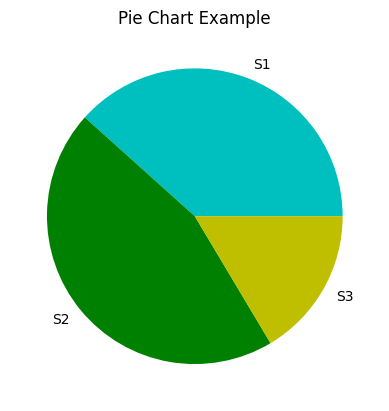

In [ ]:
import matplotlib.pyplot as plt

labels = 'S1', 'S2', 'S3'
sections = [56, 66, 24]
colors = ['c', 'g', 'y']

plt.pie(sections, labels=labels, colors=colors)
plt.title('Pie Chart Example')
plt.show()

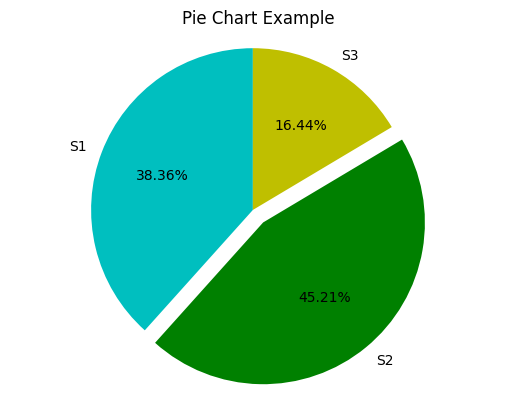

In [ ]:
import matplotlib.pyplot as plt

labels = 'S1', 'S2', 'S3'
sections = [56, 66, 24]
colors = ['c', 'g', 'y']

plt.pie(sections, labels=labels, colors=colors,
        startangle=90,
        explode = (0, 0.1, 0),
        autopct = '%1.2f%%')

plt.axis('equal') # Try commenting this out.
plt.title('Pie Chart Example')
plt.show()

### fill_between and alpha

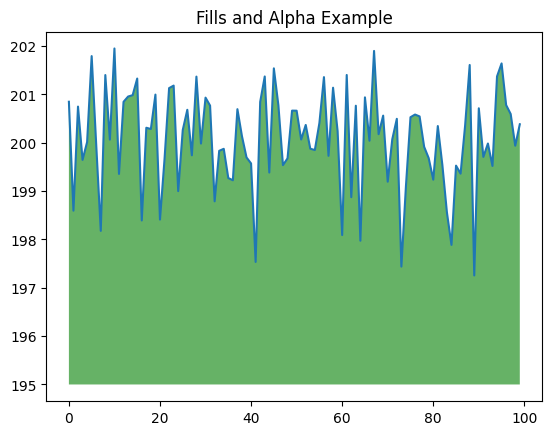

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)

plt.title("Fills and Alpha Example")
plt.show()

### Subplotting using Subplot2grid

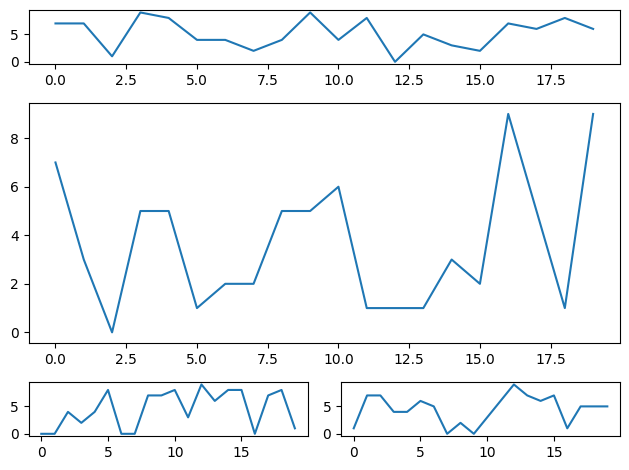

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def random_plots():
  xs = []
  ys = []

  for i in range(20):
    x = i
    y = np.random.randint(10)

    xs.append(x)
    ys.append(y)

  return xs, ys

fig = plt.figure()
ax1 = plt.subplot2grid((5, 2), (0, 0), rowspan=1, colspan=2)
ax2 = plt.subplot2grid((5, 2), (1, 0), rowspan=3, colspan=2)
ax3 = plt.subplot2grid((5, 2), (4, 0), rowspan=1, colspan=1)
ax4 = plt.subplot2grid((5, 2), (4, 1), rowspan=1, colspan=1)

x, y = random_plots()
ax1.plot(x, y)

x, y = random_plots()
ax2.plot(x, y)

x, y = random_plots()
ax3.plot(x, y)

x, y = random_plots()
ax4.plot(x, y)

plt.tight_layout()
plt.show()

## Plot styles

Colaboratory charts use [Seaborn's](https://seaborn.pydata.org) custom styling by default. To customize styling further please see the [matplotlib docs](https://matplotlib.org/users/style_sheets.html).

## 3D Graphs

### 3D Scatter Plots

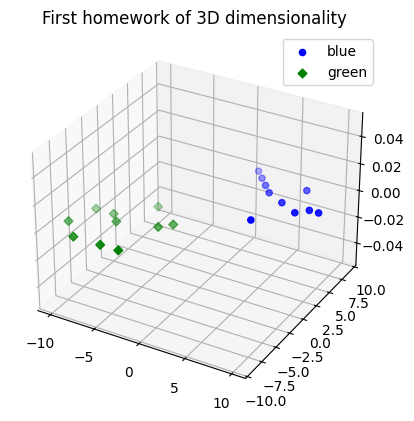

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import axes3d

fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')

x1 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y1 = np.random.randint(10, size=10)
z1 = np.zeros(10)

x2 = [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10]
y2 = np.random.randint(-10, 0, size=10)
z2 = np.zeros(10)

x3 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y3 = np.zeros(10)
z3 = np.random.randint(0, 10, size=10)

ax.scatter(x1, y1, z1, c='b', marker='o', label='blue')
ax.scatter(x2, y2, z2, c='g', marker='D', label='green')

plt.title("First homework of 3D dimensionality")
plt.legend()

plt.show()

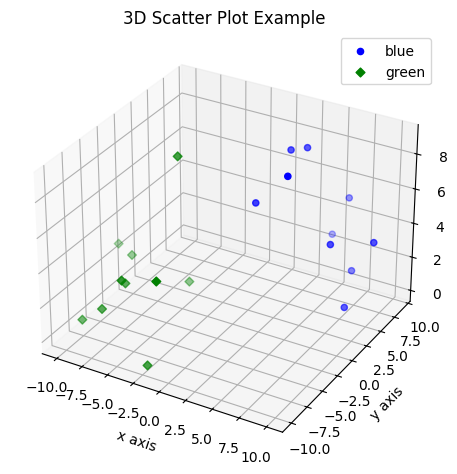

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import axes3d

fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')

x1 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y1 = np.random.randint(10, size=10)
z1 = np.random.randint(10, size=10)

x2 = [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10]
y2 = np.random.randint(-10, 0, size=10)
z2 = np.random.randint(10, size=10)

ax.scatter(x1, y1, z1, c='b', marker='o', label='blue')
ax.scatter(x2, y2, z2, c='g', marker='D', label='green')

ax.set_xlabel('x axis')
ax.set_ylabel('y axis')
ax.set_zlabel('z axis')
plt.title("3D Scatter Plot Example")
plt.legend()
plt.tight_layout()
plt.show()

### 3D Bar Plots

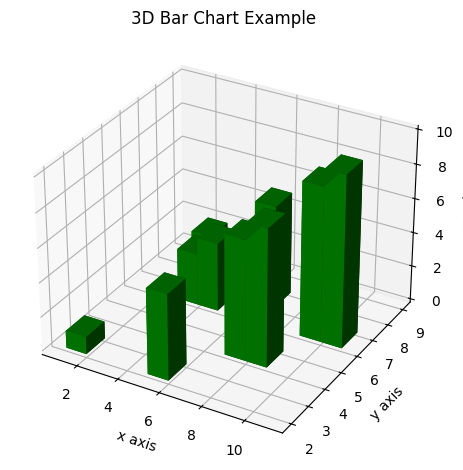

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')

x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y = np.random.randint(10, size=10)
z = np.zeros(10)

dx = np.ones(10)
dy = np.ones(10)
dz = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

ax.bar3d(x, y, z, dx, dy, dz, color='g')

ax.set_xlabel('x axis')
ax.set_ylabel('y axis')
ax.set_zlabel('z axis')
plt.title("3D Bar Chart Example")
plt.tight_layout()
plt.show()

### Wireframe Plots

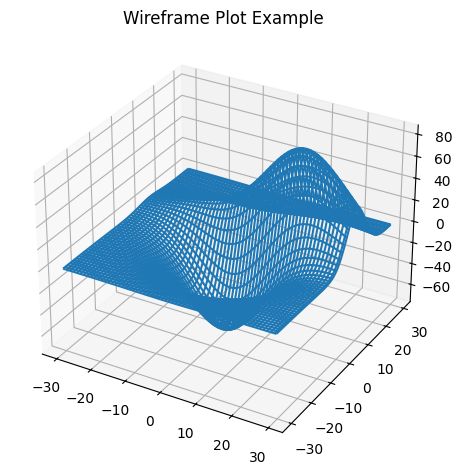

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')

x, y, z = axes3d.get_test_data()

ax.plot_wireframe(x, y, z, rstride = 2, cstride = 2)

plt.title("Wireframe Plot Example")
plt.tight_layout()
plt.show()

## Seaborn

There are several libraries layered on top of Matplotlib that you can use in Colab. One that is worth highlighting is [Seaborn](http://seaborn.pydata.org):

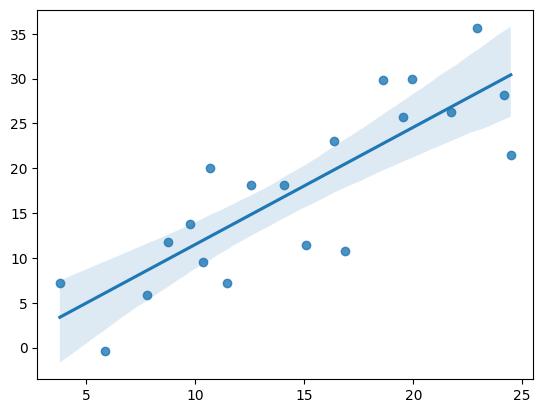

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Generate some random data
num_points = 20
# x will be 5, 6, 7... but also twiddled randomly
x = 5 + np.arange(num_points) + np.random.randn(num_points)
# y will be 10, 11, 12... but twiddled even more randomly
y = 10 + np.arange(num_points) + 5 * np.random.randn(num_points)
sns.regplot(x=x, y=y)
plt.show()

That's a simple scatterplot with a nice regression line fit to it, all with just one call to Seaborn's [regplot](http://seaborn.pydata.org/generated/seaborn.regplot.html#seaborn.regplot).

Here's a Seaborn [heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html):

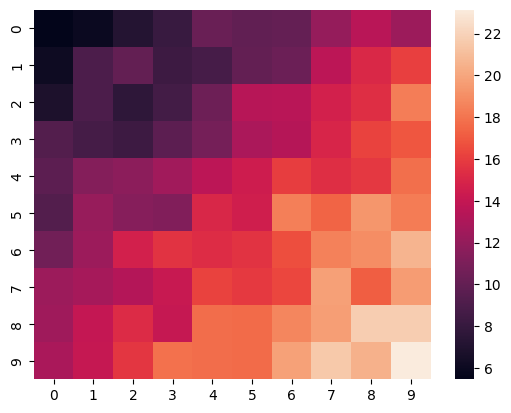

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Make a 10 x 10 heatmap of some random data
side_length = 10
# Start with a 10 x 10 matrix with values randomized around 5
data = 5 + np.random.randn(side_length, side_length)
# The next two lines make the values larger as we get closer to (9, 9)
data += np.arange(side_length)
data += np.reshape(np.arange(side_length), (side_length, 1))
# Generate the heatmap
sns.heatmap(data)
plt.show()

## Altair

[Altair](http://altair-viz.github.io) is a declarative visualization library for creating interactive visualizations in Python, and is installed and enabled in Colab by default.

For example, here is an interactive scatter plot:

In [ ]:
import altair as alt
from vega_datasets import data
cars = data.cars()

alt.Chart(cars).mark_point().encode(
    x='Horsepower',
    y='Miles_per_Gallon',
    color='Origin',
).interactive()

alt.Chart(...)

For more examples of Altair plots, see the [Altair snippets notebook](/notebooks/snippets/altair.ipynb) or the external [Altair Example Gallery](https://altair-viz.github.io/gallery/).

## Plotly

### Sample

In [ ]:
from plotly.offline import iplot
import plotly.graph_objs as go

data = [
    go.Contour(
        z=[[10, 10.625, 12.5, 15.625, 20],
           [5.625, 6.25, 8.125, 11.25, 15.625],
           [2.5, 3.125, 5., 8.125, 12.5],
           [0.625, 1.25, 3.125, 6.25, 10.625],
           [0, 0.625, 2.5, 5.625, 10]]
    )
]
iplot(data)

## Bokeh

### Sample

In [ ]:
import numpy as np
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

# Call once to configure Bokeh to display plots inline in the notebook.
output_notebook()

In [ ]:
N = 4000
x = np.random.random(size=N) * 100
y = np.random.random(size=N) * 100
radii = np.random.random(size=N) * 1.5
colors = ["#%02x%02x%02x" % (r, g, 150) for r, g in zip(np.floor(50+2*x).astype(int), np.floor(30+2*y).astype(int))]

p = figure()
p.circle(x, y, radius=radii, fill_color=colors, fill_alpha=0.6, line_color=None)
show(p)


---

# Additional Students' Practice and Answer Key

These practice questions are designed for undergraduate students. Try the **Student Practice** cell first, then compare your work with the **Completed Answer** cell.


## Student Practice 1: Matplotlib Bar Chart
Create a bar chart showing average score by class. Add a title and axis labels.

## Student Practice 2: Seaborn Scatter Plot
Create a scatter plot showing the relationship between hours studied and exam score.

In [ ]:
# Completed Answer: Visualization Practice
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame({
    'class_name': ['A', 'A', 'B', 'B', 'C', 'C'],
    'hours_studied': [2, 4, 3, 5, 1, 6],
    'score': [70, 85, 78, 90, 65, 95]
})

avg_by_class = df.groupby('class_name')['score'].mean().reset_index()

plt.figure(figsize=(6, 4))
plt.bar(avg_by_class['class_name'], avg_by_class['score'])
plt.title('Average Score by Class')
plt.xlabel('Class')
plt.ylabel('Average Score')
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='hours_studied', y='score')
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.show()